<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Image-Processing/blob/main/Image_mask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9596 - loss: 0.6813
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


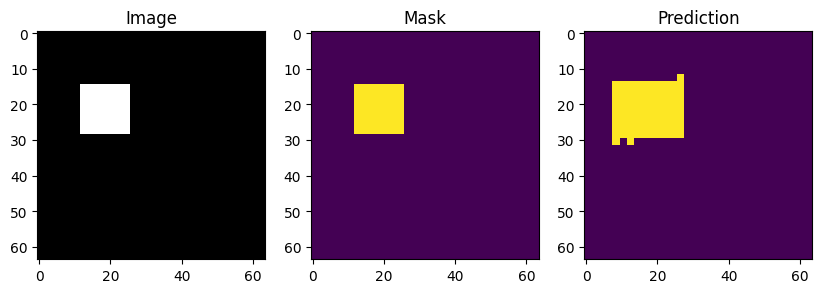

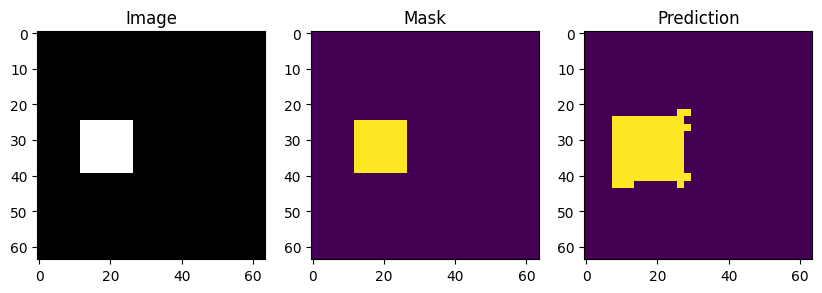

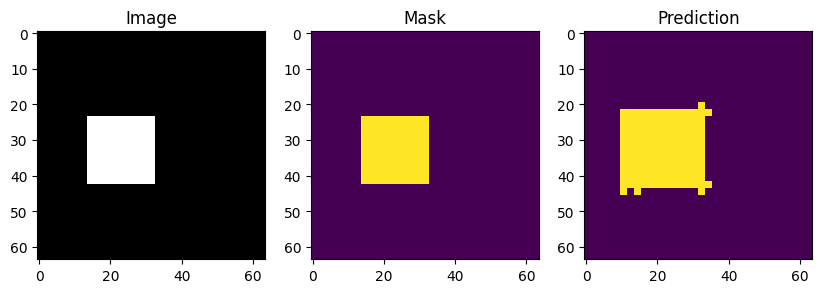

IoU: 0.9597981770833334


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 64
NUM_SAMPLES = 50

images = []
masks = []

for _ in range(NUM_SAMPLES):
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    mask = np.zeros((IMG_SIZE, IMG_SIZE, 1))

    x, y = np.random.randint(10, 40, size=2)
    w = np.random.randint(10, 20)

    img[x:x+w, y:y+w] = [1, 1, 1]
    mask[x:x+w, y:y+w] = 1

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

x = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.UpSampling2D()(x)

outputs = tf.keras.layers.Conv2D(2, 1, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(images, masks, epochs=1, batch_size=8)

def compute_iou(y_true, y_pred):
    y_pred = np.argmax(y_pred, axis=-1)
    y_true = np.squeeze(y_true)

    intersection = np.sum(y_true == y_pred)
    union = y_true.size

    return intersection / union

preds = model.predict(images[:3])

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(images[i])

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(masks[i].squeeze())

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(np.argmax(preds[i], axis=-1))

    plt.show()
iou = compute_iou(masks[:3], preds[:3])
print("IoU:", iou)